In [14]:
from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
from skimage.morphology import closing, disk, erosion, dilation, opening
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb

def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()
    
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()

In [2]:
def compute_binary(image):
    gray_image = color.rgb2gray(image)
    thresh = threshold_otsu(gray_image)
    binary = gray_image < thresh
    return binary

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_96712/812817472.py:31: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


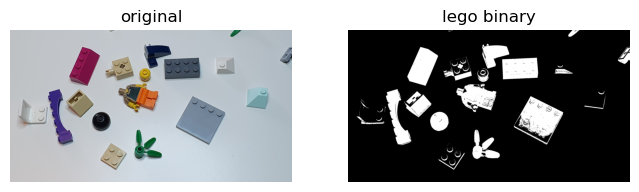

In [6]:
# 1. 
org_img = io.imread('data/lego_4_small.png')
lego_binary = compute_binary(org_img)
plot_comparison(org_img, lego_binary, "lego binary")

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_96712/812817472.py:31: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


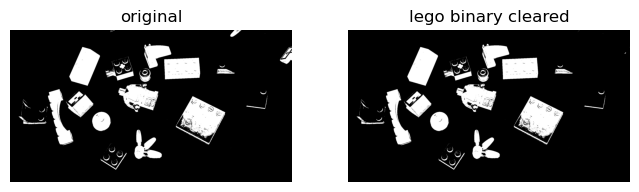

In [9]:
# 2. Use segmentation.clear_border to remove border pixels from the binary image.

lego_binary_cleared = segmentation.clear_border(lego_binary)
plot_comparison(lego_binary, lego_binary_cleared, "lego binary cleared")


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_96712/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


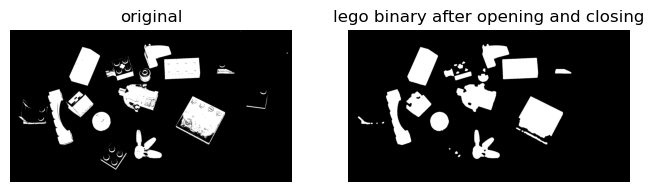

In [18]:
# 3. Cleaning using morphological operations

# closing 
closing_disk = disk(5)
closing_img = closing(lego_binary_cleared, closing_disk)

# opening
opening_disk = disk(5)
opening_img = opening(closing_img, opening_disk)

plot_comparison(lego_binary_cleared, opening_img, "lego binary after opening and closing")

In [19]:
# 4. The actual connected component analysis / BLOB analysis is performed using measure.label :
label_img = measure.label(opening_img)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")

Number of labels: 29


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_96712/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


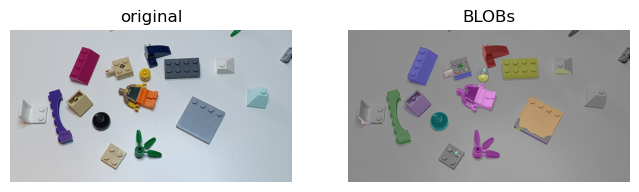

In [21]:
# 5. We can use the function label2rgb to create a visualization of the found BLOBS. 
# Show this together with the original image.
blob_img = label2rgb(label_img, image=org_img)
plot_comparison(org_img, blob_img, "BLOBs")

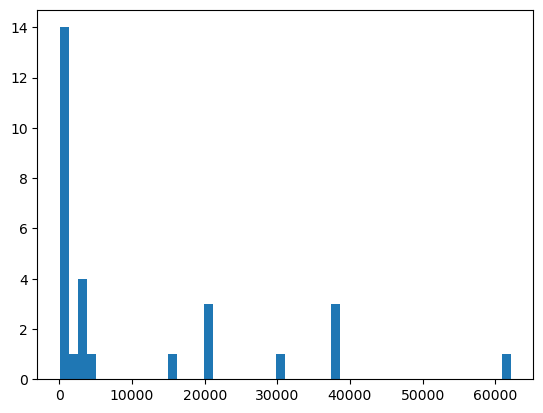

In [22]:
# 6. It is possible to compute a wide variety of 
# BLOB features using the measure.regionprops function:
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])
plt.hist(areas, bins=50)
plt.show()

In [23]:
# 7. 
import plotly
import plotly.express as px
import plotly.graph_objects as go
from skimage import data, filters, measure, morphology, io, color

# spyder fix
import plotly.io as pio 
pio.renderers.default = 'browser'

def interactive_blobs():
    in_dir = "data/"
    im_name = "lego_4_small.png"

    img_org = io.imread(in_dir + im_name)
    img = color.rgb2gray(img_org)
    # Binary image, post-process the binary mask and compute labels
    threshold = filters.threshold_otsu(img)
    mask = img < threshold
    mask = morphology.remove_small_objects(mask, 50)
    mask = morphology.remove_small_holes(mask, 50)
    labels = measure.label(mask)

    fig = px.imshow(img, binary_string=True)
    fig.update_traces(hoverinfo='skip') # hover is only for label info

    props = measure.regionprops(labels, img)
    properties = ['area', 'eccentricity', 'perimeter', 'intensity_mean']

    # For each label, add a filled scatter trace for its contour,
    # and display the properties of the label in the hover of this trace.
    for index in range(1, labels.max()):
        label_i = props[index].label
        contour = measure.find_contours(labels == label_i, 0.5)[0]
        y, x = contour.T
        hoverinfo = ''
        for prop_name in properties:
            hoverinfo += f'<b>{prop_name}: {getattr(props[index], prop_name):.2f}</b><br>'
        fig.add_trace(go.Scatter(
            x=x, y=y, name=label_i,
            mode='lines', fill='toself', showlegend=False,
            hovertemplate=hoverinfo, hoveron='points+fills'))

    plotly.io.show(fig)


if __name__ == '__main__':
    interactive_blobs()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/1864884913.py:17: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=0, vmax=40)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/1864884913.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


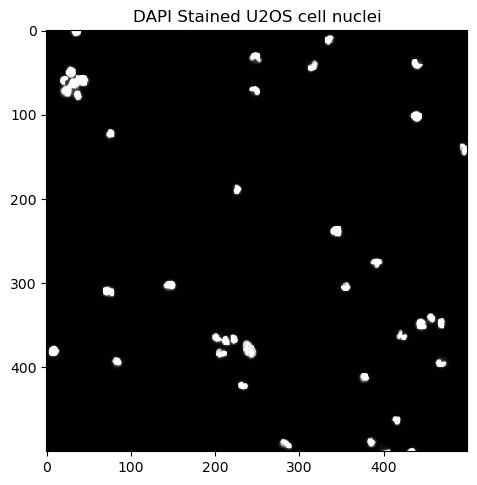

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/1864884913.py:23: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


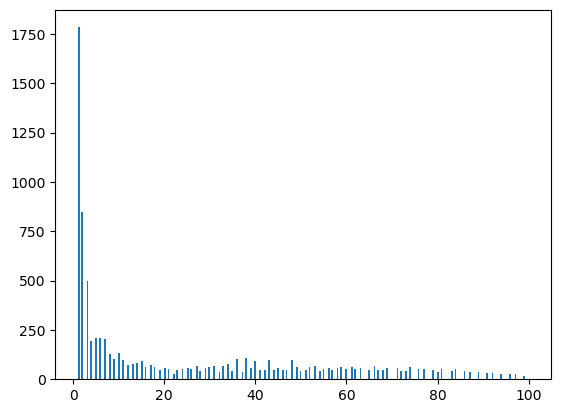

In [16]:
from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
from skimage.morphology import closing, disk, erosion, dilation, opening
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb

in_dir = "data/"
img_org = io.imread(in_dir + 'Sample E2 - U2OS DAPI channel.tiff')
# slice to extract smaller image
img_small = img_org[700:1200, 900:1400]
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=0, vmax=40)
plt.title('DAPI Stained U2OS cell nuclei')
io.show()

# avoid bin with value 0 due to the very large number of background pixels
plt.hist(img_gray.ravel(), bins=256, range=(1, 100))
io.show()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


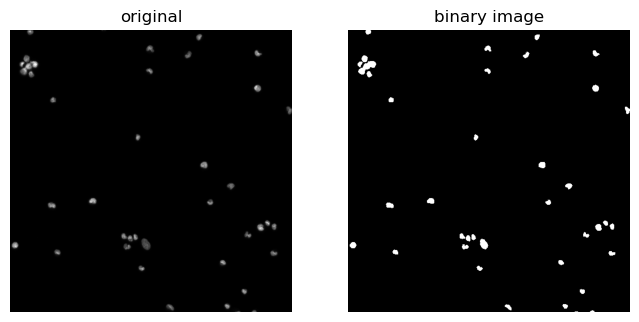

In [17]:
# 8. Threshold selection
thresh = threshold_otsu(img_gray)
img_binary = img_gray > thresh

plot_comparison(img_small, img_binary, "binary image")

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


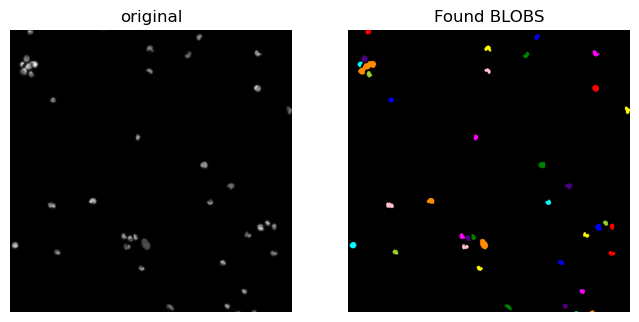

In [24]:
# 9. remove border blobs
label_img = measure.label(img_binary)
image_label_overlay = label2rgb(label_img)
plot_comparison(img_small, image_label_overlay, 'Found BLOBS')

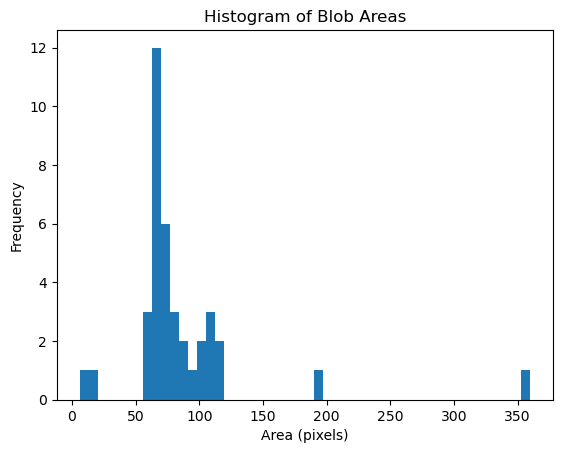

In [23]:
# 10 
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])

# We can try if the area of the objects is enough to remove invalid object.
# Plot a histogram of all the areas and see if it can be used to identify well 
# separated nuclei from overlapping nuclei and noise. 
# You should probably play around with the number of bins in your histogram plotting function.
plt.hist(areas, bins=50)
plt.title('Histogram of Blob Areas')
plt.xlabel('Area (pixels)')
plt.ylabel('Frequency')
plt.show()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


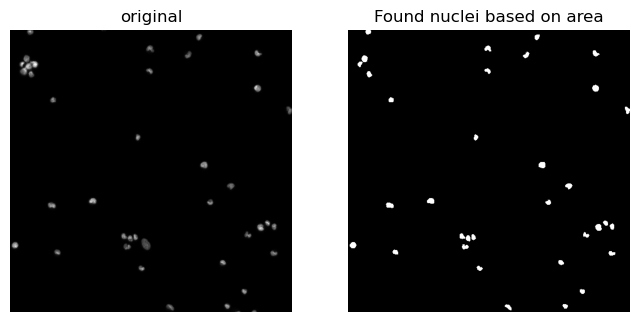

In [25]:
# 11. Select a minimum and maximum allowed area and use the following to visualise the result:
min_area = 50
max_area = 150

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
	# Find the areas that do not fit our criteria
	if region.area > max_area or region.area < min_area:
		# set the pixels in the invalid areas to background
		for cords in region.coords:
			label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
plot_comparison(img_small, i_area, 'Found nuclei based on area')

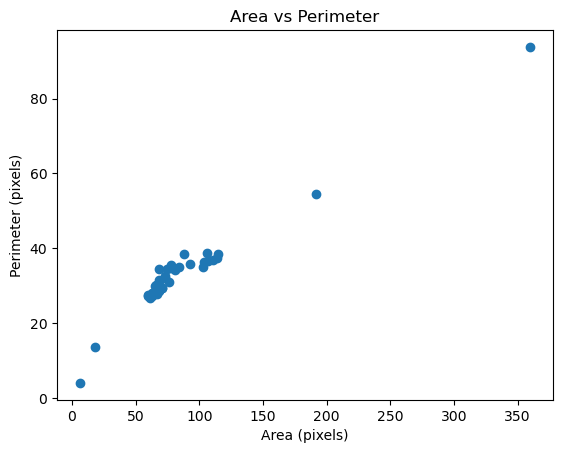

In [26]:
# 12. Extract all the perimeters of the BLOBS:
perimeters = np.array([prop.perimeter for prop in region_props])

# Try to plot the areas versus the perimeters.
plt.scatter(areas, perimeters)
plt.title('Area vs Perimeter')
plt.xlabel('Area (pixels)')
plt.ylabel('Perimeter (pixels)')
plt.show()

### Exercise 13: BLOB Circularity

We should also examine if the shape of the cells can identify them. A good measure of how circular an object is can be computed as:

$$
f_\text{circ} = \frac{4 \pi A}{P^2},
$$

where $A$ is the object area and $P$ is the perimeter. A circle has a circularity close to 1, and very-non-circular object have circularity close to 0.

Compute the circularity for all objects and plot a histogram.

Select some appropriate ranges of accepted circularity. Use these ranges to select only the cells with acceptable areas and circularity and show them in an image.

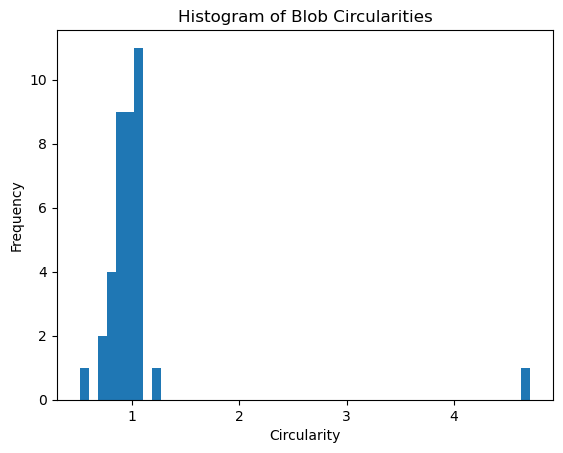

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


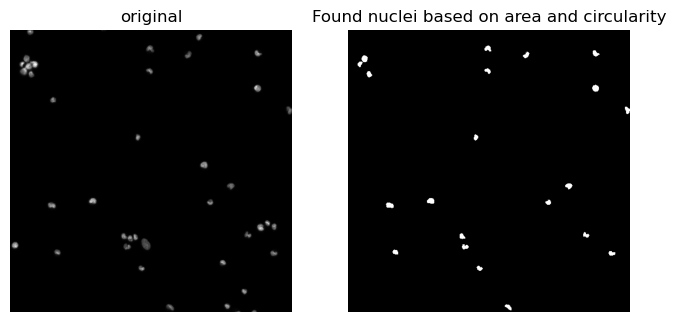

In [31]:
# 13. Compute the circularity for all objects and plot a histogram.
circularities = 4 * math.pi * areas / (perimeters ** 2)
plt.hist(circularities, bins=50)
plt.title('Histogram of Blob Circularities')
plt.xlabel('Circularity')
plt.ylabel('Frequency')
plt.show()

# Select some appropriate ranges of accepted circularity.
# Use these ranges to select only the cells with acceptable areas and circularity
# and show them in an image.

min_circularity = 0.3
max_circularity = 1.1
label_img_filter2 = label_img
for region in region_props:
    # Find the areas that do not fit our criteria
    circularity = 4 * math.pi * region.area / (region.perimeter ** 2)
    if region.area > max_area or region.area < min_area or circularity < min_circularity or circularity > max_circularity:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter2[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area2 = label_img_filter2 > 0
plot_comparison(img_small, i_area2, 'Found nuclei based on area and circularity')

Number of well-formed nuclei: 21


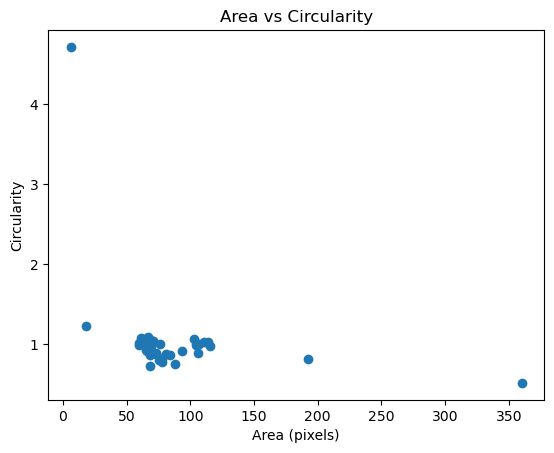

In [32]:
# 14. Try to plot the areas versus the circularity. What do you observe?
# Extend your method to return the number (the count) of well-formed nuclei in the image.

def count_well_formed_nuclei(label_img, min_area, max_area, min_circularity, max_circularity):
    region_props = measure.regionprops(label_img)
    count = 0
    for region in region_props:
        circularity = 4 * math.pi * region.area / (region.perimeter ** 2)
        if min_area <= region.area <= max_area and min_circularity <= circularity <= max_circularity:
            count += 1
    return count

n_well_formed_nuclei = count_well_formed_nuclei(label_img, min_area, max_area, min_circularity, max_circularity)
print(f"Number of well-formed nuclei: {n_well_formed_nuclei}")

# Plot areas vs circularities
plt.scatter(areas, circularities)
plt.title('Area vs Circularity')
plt.xlabel('Area (pixels)')
plt.ylabel('Circularity')
plt.show()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/1105401141.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(larger_img_gray, vmin=0, vmax=40)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/1105401141.py:8: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


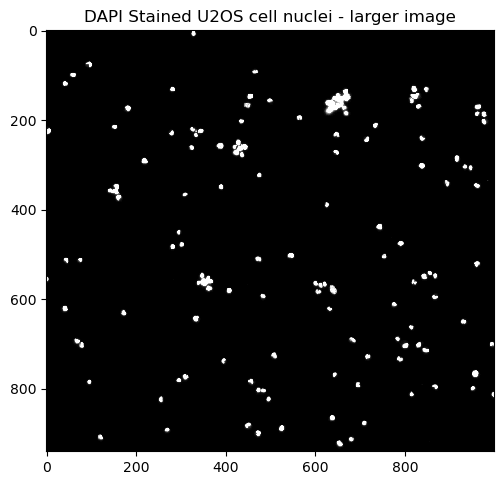

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/3527716060.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


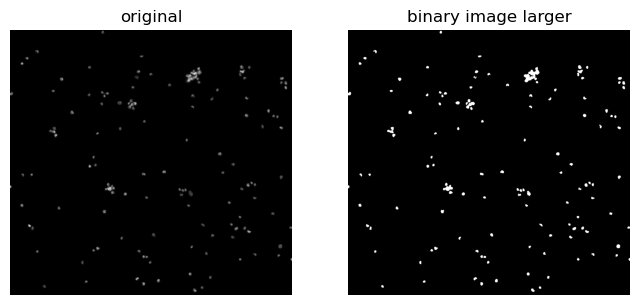

Number of well-formed nuclei in larger image: 112


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_97598/755668556.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  circularity = 4 * math.pi * region.area / (region.perimeter ** 2)


In [33]:
# 15 Try to test the method on a larger set of training images. 
# Use slicing to select the different regions from the raw image.

larger_img = img_org[500:1500, 500:1500]
larger_img_gray = img_as_ubyte(larger_img)
io.imshow(larger_img_gray, vmin=0, vmax=40)
plt.title('DAPI Stained U2OS cell nuclei - larger image')
io.show()
thresh = threshold_otsu(larger_img_gray)
larger_img_binary = larger_img_gray > thresh
plot_comparison(larger_img, larger_img_binary, "binary image larger")
label_img_larger = measure.label(larger_img_binary)
n_well_formed_nuclei_larger = count_well_formed_nuclei(label_img_larger, min_area, max_area, min_circularity, max_circularity)
print(f"Number of well-formed nuclei in larger image: {n_well_formed_nuclei_larger}")


In [ ]:
# 16. 